In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
)

# --- CẤU HÌNH TOÀN CỤC ---
# Dataset gốc từ Kaggle: uciml/pima-indians-diabetes-database
KAGGLE_DATASET_REF = "uciml/pima-indians-diabetes-database"
DATA_PATH = "diabetes.csv"
FALLBACK_DATA_URL = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
TARGET_COL = 'Outcome'  # Tên cột chứa nhãn phân lớp
TEST_SIZE = 0.3         # Tỷ lệ 70/30
K_FOLDS = 10            # Số lượng Folds cho Cross-Validation
RANDOM_STATE = 42       # Cố định random seed để kết quả ổn định

# Khởi tạo các cấu trúc lưu trữ kết quả toàn cục
results_list = []
roc_data = {}

In [2]:
# 1. Tải dữ liệu
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Đã đọc dữ liệu từ file local: {DATA_PATH}")
except FileNotFoundError:
    df = pd.read_csv(FALLBACK_DATA_URL)
    print("Không tìm thấy file local, dùng fallback URL.")

print(f"Kích thước bộ dữ liệu: {df.shape}")
print(df[TARGET_COL].value_counts())

# 2. Tách X và y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 3. Viết hàm đánh giá dùng chung để tái sử dụng
def evaluate_and_record(y_true, y_pred, y_prob, method_name, model_name):
    # Tính toán các metric
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    # Vẽ Confusion Matrix trực tiếp bằng matplotlib
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax)
    ax.set_title(f"Confusion Matrix - {model_name} ({method_name})")
    ax.grid(False)
    plt.tight_layout()
    plt.show()
    
    # Tính toán cho ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[f"{model_name} ({method_name})"] = (fpr, tpr, roc_auc)
    
    # Lưu kết quả
    results_list.append({
        'Method': method_name, 
        'Model': model_name, 
        'Accuracy': acc, 
        'Precision': prec, 
        'Recall': rec, 
        'F1-Score': f1, 
        'AUC': roc_auc
    })

Không tìm thấy file local, dùng fallback URL.
Kích thước bộ dữ liệu: (768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64


In [13]:
# Định nghĩa các mô hình theo yêu cầu
# Chọn C4.5 cho nhánh Decision Tree (phù hợp hơn với dữ liệu số liên tục như Pima)
# Lưu ý: sklearn không có C4.5 thuần; dùng entropy tree như phương án gần nhất trong thực hành
models = {
    "DT_C45": {
        "estimator": DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE),
        "use_scaler": False
    },
    "DT_CART": {
        "estimator": DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE),
        "use_scaler": False
    },
    "Gradient_Boosting": {
        "estimator": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "use_scaler": False
    },
    "Gaussian_NB": {
        "estimator": GaussianNB(),
        "use_scaler": True
    },
    "Bernoulli_NB": {
        "estimator": BernoulliNB(binarize=0.0),
        "use_scaler": True
    }
}

def build_estimator(model_cfg):
    base_estimator = clone(model_cfg["estimator"])
    if model_cfg["use_scaler"]:
        return Pipeline(steps=[("scaler", StandardScaler()), ("model", base_estimator)])
    return base_estimator

print(f"Đã tải {len(models)} mô hình sẵn sàng huấn luyện.")

Đã tải 5 mô hình sẵn sàng huấn luyện.


BẮT ĐẦU HUẤN LUYỆN: TỶ LỆ 70/30


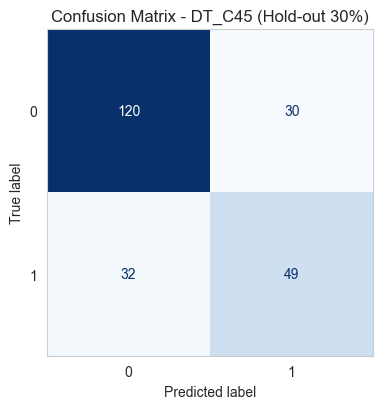

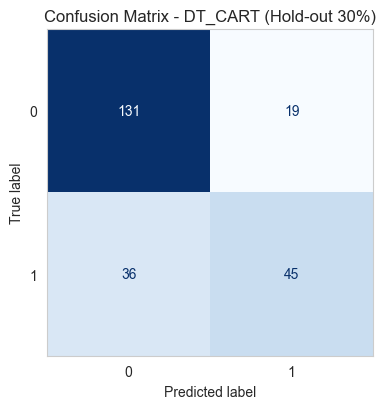

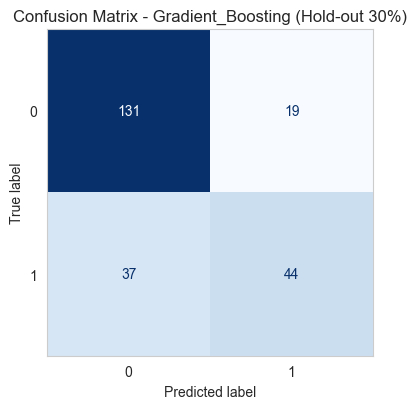

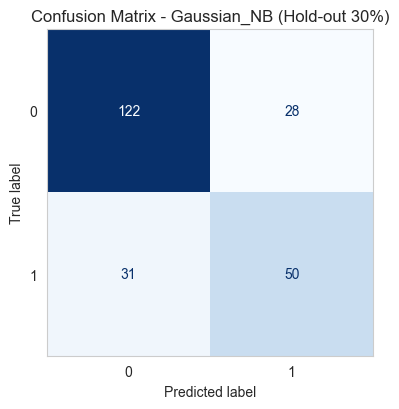

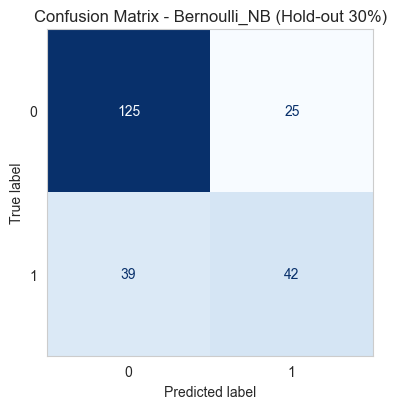

In [14]:
print("="*60)
print(f"BẮT ĐẦU HUẤN LUYỆN: TỶ LỆ {(1-TEST_SIZE)*100:.0f}/{TEST_SIZE*100:.0f}")
print("="*60)

# Làm sạch kết quả cũ để tránh cộng dồn khi chạy lại notebook nhiều lần
results_list.clear()
roc_data.clear()

# stratify=y đảm bảo tỷ lệ nhãn (0/1) trong tập train/test bằng với tập gốc
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

for name, cfg in models.items():
    estimator = build_estimator(cfg)
    
    # Fit mô hình
    estimator.fit(X_train, y_train)
    
    # Dự đoán
    y_pred = estimator.predict(X_test)
    y_prob = estimator.predict_proba(X_test)[:, 1]  # Lấy xác suất của class 1
    
    # Đánh giá
    evaluate_and_record(y_test, y_pred, y_prob, f"Hold-out {int(TEST_SIZE*100)}%", name)

BẮT ĐẦU HUẤN LUYỆN: K-FOLD CROSS VALIDATION (K=10)


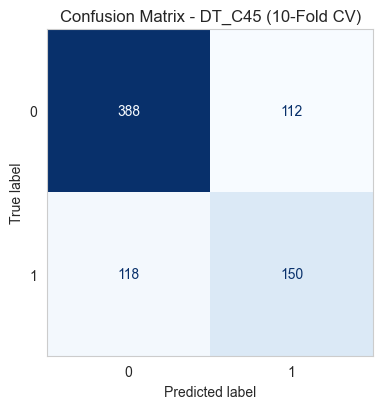

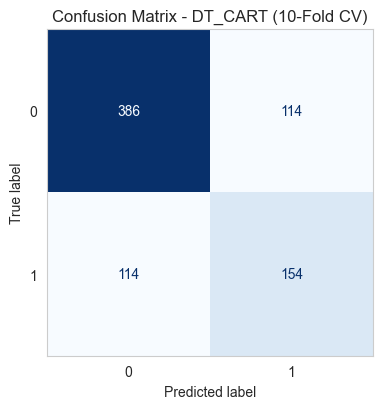

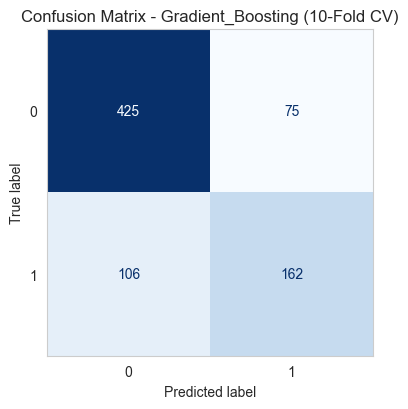

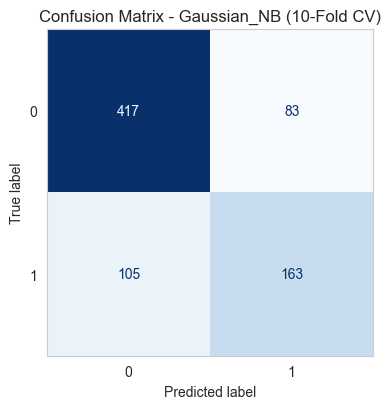

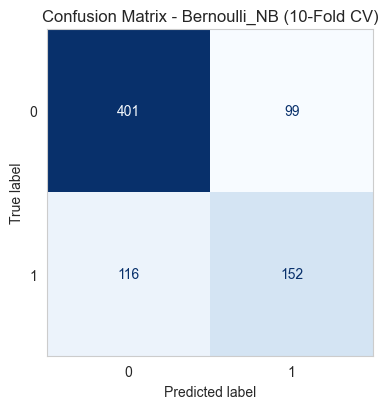

In [15]:
print("="*60)
print(f"BẮT ĐẦU HUẤN LUYỆN: K-FOLD CROSS VALIDATION (K={K_FOLDS})")
print("="*60)

# Khởi tạo StratifiedKFold
cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for name, cfg in models.items():
    estimator = build_estimator(cfg)
    
    # Sử dụng cross_val_predict để giả lập lại toàn bộ quá trình predict qua 10 folds
    y_pred_cv = cross_val_predict(estimator, X, y, cv=cv)
    
    # Lấy xác suất cho AUC
    y_prob_cv = cross_val_predict(estimator, X, y, cv=cv, method='predict_proba')[:, 1]
    
    # Đánh giá tổng quát trên toàn bộ dữ liệu (y)
    evaluate_and_record(y, y_pred_cv, y_prob_cv, f"{K_FOLDS}-Fold CV", name)

BẢNG TỔNG HỢP CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH
      Method             Model  Accuracy  Precision  Recall  F1-Score    AUC
Hold-out 30%       Gaussian_NB    0.7446     0.6410  0.6173    0.6289 0.8088
Hold-out 30%           DT_CART    0.7619     0.7031  0.5556    0.6207 0.7144
Hold-out 30%            DT_C45    0.7316     0.6203  0.6049    0.6125 0.7025
Hold-out 30% Gradient_Boosting    0.7576     0.6984  0.5432    0.6111 0.8348
Hold-out 30%      Bernoulli_NB    0.7229     0.6269  0.5185    0.5676 0.8031
  10-Fold CV Gradient_Boosting    0.7643     0.6835  0.6045    0.6416 0.8310
  10-Fold CV       Gaussian_NB    0.7552     0.6626  0.6082    0.6342 0.8115
  10-Fold CV      Bernoulli_NB    0.7201     0.6056  0.5672    0.5857 0.7733
  10-Fold CV           DT_CART    0.7031     0.5746  0.5746    0.5746 0.6733
  10-Fold CV            DT_C45    0.7005     0.5725  0.5597    0.5660 0.6679


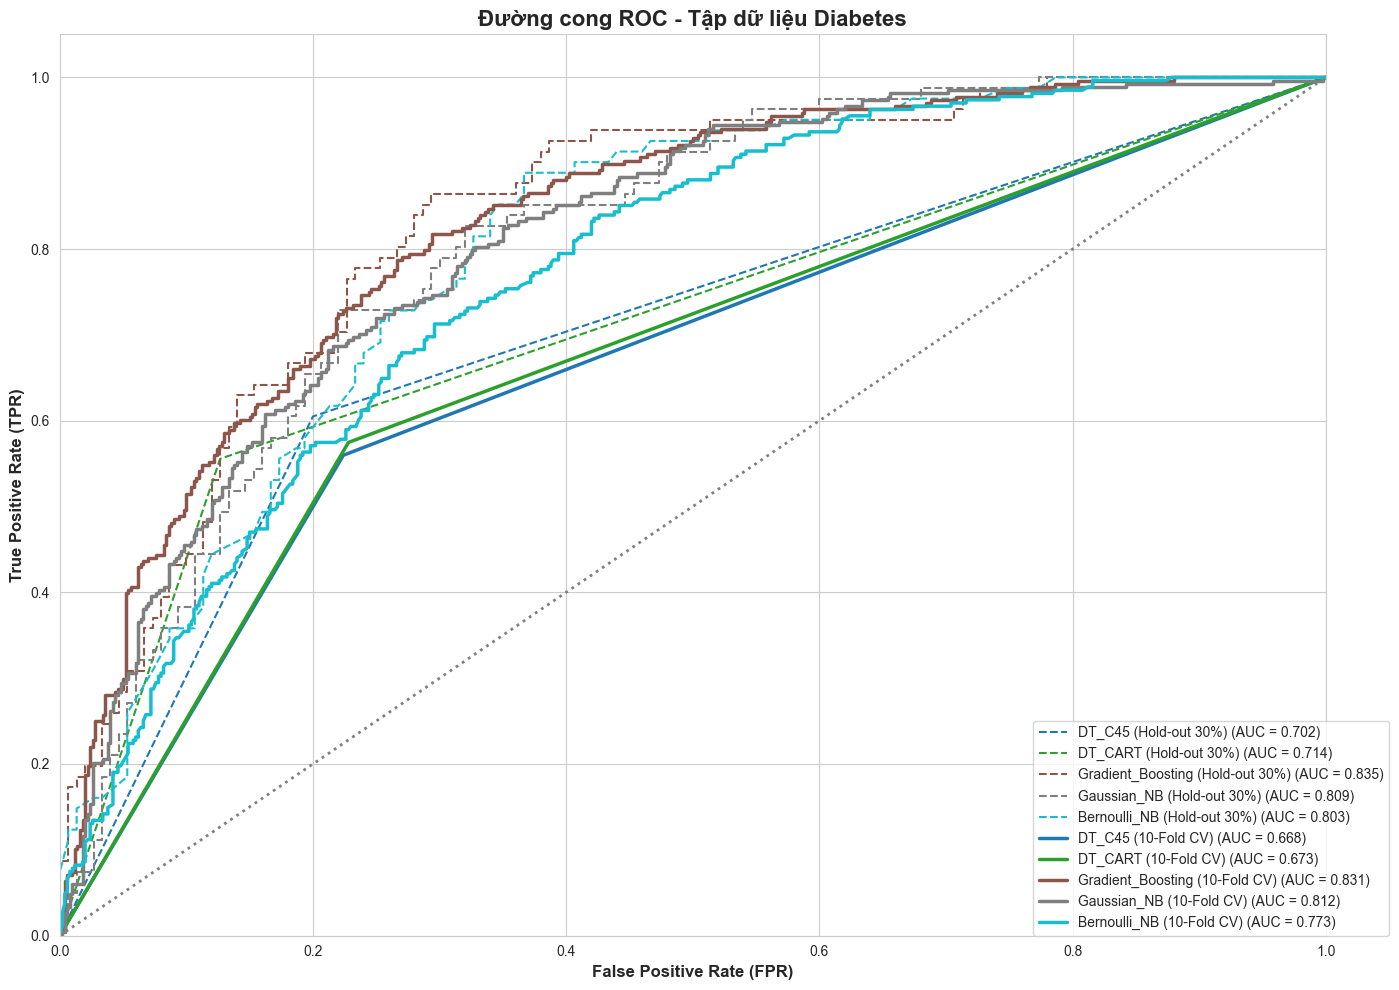

In [16]:
# 1. XUẤT BẢNG KẾT QUẢ
results_df = pd.DataFrame(results_list)
# Sắp xếp theo Phương pháp, sau đó ưu tiên F1-Score cao nhất
results_df = results_df.sort_values(by=['Method', 'F1-Score'], ascending=[False, False]).reset_index(drop=True)

print("="*80)
print("BẢNG TỔNG HỢP CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH")
print("="*80)
# Highlight kết quả cho đẹp (Chỉ hoạt động tốt trên Jupyter Notebook)
try:
    display(results_df.style.background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']).format(precision=4))
except:
    # Fallback nếu chạy trên terminal thường
    print(results_df.round(4).to_string(index=False))


# 2. VẼ BIỂU ĐỒ ROC
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# Phân bổ màu sắc tự động (Không hardcode màu)
cmap = plt.get_cmap("tab10")
colors = cmap(np.linspace(0, 1, len(models)))
model_color_map = {list(models.keys())[i]: colors[i] for i in range(len(models))}

for key, (fpr, tpr, roc_auc) in roc_data.items():
    # Bóc tách tên model và phương pháp từ chuỗi 'ModelName (Method)'
    model_name, method_name = key.split(" (")
    
    # Hold-out vẽ nét đứt, K-Fold vẽ nét liền
    linestyle = '--' if 'Hold-out' in method_name else '-'
    linewidth = 2.5 if 'CV' in method_name else 1.5
    
    plt.plot(fpr, tpr, linestyle=linestyle, lw=linewidth, color=model_color_map[model_name],
             label=f"{key} (AUC = {roc_auc:.3f})")

# Đường chuẩn (random guess)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
plt.title(f'Đường cong ROC - Tập dữ liệu Diabetes', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, bbox_to_anchor=(1.05, 0), borderaxespad=0.)
plt.tight_layout()
plt.show()